# Speech Emotion Recognition — Speech Transformers & Self-Supervised Learning (SSL) Models

**Notebook 4 of 4** in the RAVDESS series.

| Notebook | Focus |
|----------|-------|
| 1 | Classical ML on hand-crafted features (MFCCs, Chroma, Spectral) |
| 2 | CNN on mel-spectrograms — regularization, augmentation, transfer learning |
| 3 | CNN + sequential and attention modules — BiLSTM, Attention Pooling, MHSA |
| **4** | **Speech Transformers & Self-Supervised Learning (SSL) Models — Wav2Vec 2.0, HuBERT, WavLM, Whisper** |

### Research Question

> How do modern Self-Supervised Learning (SSL) speech representation models compare to standard 2D image CNNs for Speech Emotion Recognition, both in zero-shot feature extraction and fine-tuned settings?

In Notebook 2, we saw that transfer learning from an ImageNet-pretrained 2D CNN (ResNet18) reached **87.04%** accuracy. However, visual spectrogram representations lack speech-specific priors. This notebook evaluates models pre-trained on raw speech waveforms (SSL models) to test if learning from raw audio waveforms improves classification.

### Models Evaluated

| # | Model | Pre-training Paradigm | Key Advantage |
|---|-------|-----------------------|---------------|
| 1 | **Wav2Vec 2.0** | Contrastive predictive coding | Pioneer of raw audio SSL representations |
| 2 | **HuBERT** | Masked Language Modeling over K-Means units | Learns clean phonetic and acoustic codebooks |
| 3 | **WavLM** | Masked MLM + speech denoising / speaker overlap simulation | State-of-the-Art for prosody & speaker traits |
| 4 | **Whisper** | Large-scale supervised multitasking | Supervised baseline trained on 680k hours of audio |

### Evaluation Framework

For each model, we will perform two tests:
1.  **Frozen Encoder (Zero-Shot Linear Probing)**: We freeze the pre-trained backbone, extract frame-level sequence embeddings, and train a shallow classification head (from Notebook 3) on top. This tests the quality of the frozen representation.
2.  **Full Fine-Tuning**: We unfreeze the backbone weights and train the entire network end-to-end to adapt the representations directly to emotional classification.

## 0. Environment Setup

Installs Hugging Face's `transformers`, `datasets`, and audio-processing libraries like `soundfile` and `librosa`.

In [1]:
!pip uninstall -y torch torchvision torchaudio -q
!pip install torch==2.7.1 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 214.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 234.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 199.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 69.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 88.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.2/200.2 MB 127.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 188.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 158.2/158.2 MB 142.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 MB 125.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 136.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 126.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━

In [2]:
# Install transformers, datasets, accelerate, and soundfile
!pip install transformers datasets accelerate soundfile -q

import os
import random
import warnings
import json

import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings("ignore")

SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Data Loading & Resampling (16kHz)

> **Crucial Acoustic Note**: Speech Transformers (Wav2Vec 2.0, HuBERT, WavLM) are pre-trained on speech sampled at **16,000 Hz**. In previous notebooks, we loaded audio at 22,050 Hz. We must resample the audio to 16,000 Hz to prevent domain shift and severe model performance degradation.

In [3]:
# Configuration
TARGET_SR = 16000
DURATION = 4  # seconds
MAX_SAMPLES = TARGET_SR * DURATION
data_source_path = '/kaggle/input'


# Scan Kaggle Input Directory for WAV files
wav_files = []
for dirname, _,filenames in os.walk(data_source_path):
    for filename in filenames:
        if filename.endswith('.wav'):
            wav_files.append(os.path.join(dirname,filename))

print(f"Total audio files found: {len(wav_files):,}")

# Map RAVDESS Codes to Emotion Labels
EMOTIONS_MAP = {
    "01": "neutral",  "02": "calm",     "03": "happy",
    "04": "sad",      "05": "angry",    "06": "fearful",
    "07": "disgust",  "08": "surprised"
    }


def get_emotion(path: str) -> str:
    code = os.path.basename(path).split("-")[2]
    return EMOTIONS_MAP.get(code, "unknown")

columns = {
    "path": wav_files,
    "emotion": [get_emotion(path) for path in wav_files]

}

df = pd.DataFrame(columns)
df = df[df["emotion"] != "unknown"].reset_index(drop=True)
print(f"Dataset shape: {df.shape}")

# Load & Resample Waveforms to 16,000 Hz in RAM
X_raw = []
for path in tqdm(df["path"],desc="Loading raw waveforms at 16kHz"):
    # Resample on-the-fly during load
    signal, sr = librosa.load(path, sr=TARGET_SR)

    # Pad to exact length if too short, truncate if too long
    if len(signal) < MAX_SAMPLES:
        signal = np.pad(signal, (0, MAX_SAMPLES - len(signal)))
    else:
        signal = signal[:MAX_SAMPLES]

    X_raw.append(signal)

X_raw = np.array(X_raw, dtype=np.float32)

# Encode Class Labels
encoder = LabelEncoder()
y = encoder.fit_transform(df["emotion"])
classes = list(encoder.classes_)
print(f"Loaded {len(X_raw)} waveforms of shape {X_raw.shape[1]:,}. Target classes: {classes}")


# Create Stratified Train / Val / Test Splits (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.30, stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)
print(f"Train samples: {X_train.shape[0]} | Val samples: {X_val.shape[0]} | Test samples: {X_test.shape[0]}")

Total audio files found: 1,440
Dataset shape: (1440, 2)


Loading raw waveforms at 16kHz: 100%|██████████| 1440/1440 [00:29<00:00, 49.21it/s]


Loaded 1440 waveforms of shape 64,000. Target classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
Train samples: 1008 | Val samples: 216 | Test samples: 216


## 2. Shared Evaluation & Fine-Tuning Pipeline

Common utilities to handle frozen feature extraction, training loops, early stopping, and zero-shot probing.

In [4]:
results = {}  # Store results: results[model_name] = {'zero_shot_acc': ..., 'fine_tuned_acc': ...}

# Custom Dataset Wrapper
class AudioDataset(Dataset):
    """Plain dataset — shape (raw_waveform,)."""
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
        
    def __len__(self):  
        return len(self.X)
        
    def __getitem__(self, idx): 
        return self.X[idx], self.y[idx]

# Dynamic Hugging Face Collator Generator
def make_collate_fn(processor, model_type="ssl"):
    """
    Creates a collate function for the PyTorch DataLoader using Hugging Face processors.
    model_type: 'ssl' (Wav2Vec2/HuBERT/WavLM) or 'whisper'
    """
    def collate_fn(batch):
        # Extract raw waveforms (converted to float list) and labels
        waveforms = [item[0].numpy() for item in batch]
        labels = [item[1].item() for item in batch]
        
        if model_type == "whisper":
            # Whisper processor converts raw audio into Mel-Spectrogram features
            inputs = processor(waveforms, sampling_rate=16000, return_tensors="pt")
            return {
                "input_features": inputs.input_features,
                "labels": torch.tensor(labels)
            }
        else:
            # SSL models expect normalized raw waveform sequences and attention masks
            inputs = processor(waveforms, sampling_rate=16000, padding=True, return_tensors="pt")
            batch_dict = {
                "input_values": inputs.input_values,
                "labels": torch.tensor(labels)
            }
            if "attention_mask" in inputs:
                batch_dict["attention_mask"] = inputs.attention_mask
            return batch_dict
            
    return collate_fn

# Model Training Loop with Early Stopping
def train_model(model, train_loader, val_loader, optimizer, scheduler=None, 
                criterion=None, num_epochs=30, patience=5, model_name="model", model_type="ssl"):
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
        
    best_val_loss = float("inf")
    counter = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    ckpt_path = f"{model_name}_best.pth"
    
    for epoch in range(num_epochs):
        # ---- Train ----
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch in train_loader:
            optimizer.zero_grad()
            labels = batch["labels"].to(device)
            
            # Forward pass depending on architecture
            if model_type == "whisper":
                input_features = batch["input_features"].to(device)
                outputs = model(input_features=input_features)
            else:
                input_values = batch["input_values"].to(device)
                attention_mask = batch["attention_mask"].to(device) if "attention_mask" in batch else None
                outputs = model(input_values=input_values, attention_mask=attention_mask)
                
            logits = outputs.logits
            loss = criterion(logits, labels)
            
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        
        # ---- Validate ----
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for batch in val_loader:
                labels = batch["labels"].to(device)
                
                if model_type == "whisper":
                    input_features = batch["input_features"].to(device)
                    outputs = model(input_features=input_features)
                else:
                    input_values = batch["input_values"].to(device)
                    attention_mask = batch["attention_mask"].to(device) if "attention_mask" in batch else None
                    outputs = model(input_values=input_values, attention_mask=attention_mask)
                    
                logits = outputs.logits
                loss = criterion(logits, labels)
                
                running_loss += loss.item()
                _, predicted = torch.max(logits, 1)
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
                
        val_loss = running_loss / len(val_loader)
        val_acc = correct / total
        
        if scheduler is not None:
            scheduler.step(val_loss)
            
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
              
        # Early Stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1} (best val loss={best_val_loss:.4f})")
                break
                
    # Load best checkpoint
    model.load_state_dict(torch.load(ckpt_path))
    return model, history

# Standardized Model Evaluation
@torch.no_grad()
def evaluate_model(model, loader, model_type="ssl"):
    model.eval()
    y_true, y_pred = [], []
    
    for batch in loader:
        labels = batch["labels"]
        
        if model_type == "whisper":
            input_features = batch["input_features"].to(device)
            outputs = model(input_features=input_features)
        else:
            input_values = batch["input_values"].to(device)
            attention_mask = batch["attention_mask"].to(device) if "attention_mask" in batch else None
            outputs = model(input_values=input_values, attention_mask=attention_mask)
            
        logits = outputs.logits
        _, predicted = torch.max(logits, 1)
        
        y_true.extend(labels.numpy())
        y_pred.extend(predicted.cpu().numpy())
        
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred

## 3. Model 1 — Wav2Vec 2.0

*   **Paper**: ["wav2vec 2.0: A Framework for Self-Supervised Learning of Speech Representations" (Baevski et al., NeurIPS 2020)](https://arxiv.org/abs/2006.11477)
*   **Core Concept**: Uses a CNN encoder to project raw audio to latent features, which are then masked. A Transformer learns context representations over masked segments by solving a contrastive task against quantized representations of the raw features.

### Key Concepts to Understand About Wav2Vec 2.0:

1. **Self-Supervised Learning (SSL) Paradigm**
   It learns the fundamental physics and patterns of human speech by listening to thousands of hours of unlabeled raw audio waveforms—completely bypassing the need for expensive transcripts.

2. **1D Temporal CNN Encoder (Local Context)**
   Raw 1D audio waves (16kHz) are downsampled by a temporal Convolutional Neural Network into feature representations at 50Hz, extracting local embeddings representing **20ms slices** of audio.

3. **Transformer Context Network (Global Context)**
   Employs a BERT-style self-attention network to capture long-range interactions across the sequence, allowing the model to understand how speech sounds change and flow over time.

4. **Vector Quantization (The Codebook)**
   Since continuous audio waves have no natural "words," the model uses a Gumbel-Softmax sampler to map continuous CNN vectors into discrete templates (from a learned **Codebook**). This acts as a discrete "sound dictionary."

5. **Contrastive Masked Pre-training**
   Roughly 49% of the CNN audio frames are masked (hidden) before entering the Transformer. The model's training goal is to predict the correct hidden codebook sound out of 100 random "distractor" sounds.

6. **Task-Agnostic Backbone**
   Because it learns representations of how speech *behaves* (phonetics, speaker tone, speed) rather than specific text transcripts, the same pre-trained backbone can be adapted to completely different tasks.

7. **Downstream Adaptation (Head Swap)**
   For downstream tasks like Speech Emotion Recognition (SER), the pre-training quantization codebook is discarded. We attach a task-specific classification head (e.g. Linear classifier) on top of the Transformer's output to map the learned vectors to our target emotions.

In [5]:
from transformers import Wav2Vec2Processor, Wav2Vec2ForSequenceClassification

model_id = "facebook/wav2vec2-base"
processor = Wav2Vec2Processor.from_pretrained(model_id)

# Initialize Datasets and Dataloaders
collate_fn = make_collate_fn(processor, model_type="ssl")

train_dataset = AudioDataset(X_train, y_train)
val_dataset = AudioDataset(X_val, y_val)
test_dataset = AudioDataset(X_test, y_test)


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

In [6]:
# Test 1: Frozen Backbone (Linear Probing)
def count_parameters(model):
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable Parameters: {trainable_params:,} | Total Parameters: {total_params:,} | Trainable %: {100 * trainable_params / total_params:.4f}%")


print("--- Training Wav2Vec 2.0 in FROZEN (Probing) Mode ---")
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    model_id, 
    num_labels=len(classes)
).to(device)

# Freeze the pre-trained transformer layers
for param in model.wav2vec2.parameters():
    param.requires_grad = False

# Print parameter count before setting up the optimizer
count_parameters(model)

# Optimize only the unfrozen parameters (the classifier head)
optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-3)

model, history_frozen = train_model(
    model, train_loader, val_loader, optimizer,
    num_epochs=200, patience=10, model_name="wav2vec2_frozen", model_type="ssl"
)

acc_frozen, yt_frozen, yp_frozen = evaluate_model(model, test_loader, model_type="ssl")

results["Wav2Vec 2.0 (Frozen)"] = {
    "train_acc": history_frozen["train_acc"][-1],
    "test_acc": acc_frozen,
    "gap": history_frozen["train_acc"][-1] - acc_frozen
}

print(f"Wav2Vec 2.0 (Frozen) Test Accuracy: {acc_frozen:.4f}")

--- Training Wav2Vec 2.0 in FROZEN (Probing) Mode ---


pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
projector.weight             | MISSING    | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable Parameters: 198,920 | Total Parameters: 94,570,632 | Trainable %: 0.2103%


model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Epoch 01 | Train Loss: 1.9207 Acc: 0.2312 | Val Loss: 1.7696 Acc: 0.2824
Epoch 02 | Train Loss: 1.6677 Acc: 0.3671 | Val Loss: 1.6183 Acc: 0.3380
Epoch 03 | Train Loss: 1.5130 Acc: 0.4206 | Val Loss: 1.5260 Acc: 0.4306
Epoch 04 | Train Loss: 1.4069 Acc: 0.4851 | Val Loss: 1.4488 Acc: 0.4398
Epoch 05 | Train Loss: 1.3556 Acc: 0.4772 | Val Loss: 1.5165 Acc: 0.4213
Epoch 06 | Train Loss: 1.3100 Acc: 0.4841 | Val Loss: 1.3803 Acc: 0.4907
Epoch 07 | Train Loss: 1.2594 Acc: 0.5188 | Val Loss: 1.3391 Acc: 0.5000
Epoch 08 | Train Loss: 1.2042 Acc: 0.5466 | Val Loss: 1.3848 Acc: 0.5185
Epoch 09 | Train Loss: 1.1646 Acc: 0.5764 | Val Loss: 1.3169 Acc: 0.4907
Epoch 10 | Train Loss: 1.1203 Acc: 0.5813 | Val Loss: 1.2336 Acc: 0.5556
Epoch 11 | Train Loss: 1.1074 Acc: 0.5853 | Val Loss: 1.3656 Acc: 0.5000
Epoch 12 | Train Loss: 1.0965 Acc: 0.6002 | Val Loss: 1.2304 Acc: 0.5278
Epoch 13 | Train Loss: 1.0888 Acc: 0.5923 | Val Loss: 1.3966 Acc: 0.4722
Epoch 14 | Train Loss: 1.0992 Acc: 0.5863 | Val Los

In [7]:
# Test 2: Full Fine-Tuning

print("\n--- Training Wav2Vec 2.0 in FINE-TUNED Mode ---")
model = Wav2Vec2ForSequenceClassification.from_pretrained(
    model_id, 
    num_labels=len(classes)
).to(device)

# Optimize all parameters with a low learning rate
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
model, history_tuned = train_model(
    model, train_loader, val_loader, optimizer,
    num_epochs=200, patience=10, model_name="wav2vec2_tuned", model_type="ssl"
)
acc_tuned, yt_tuned, yp_tuned = evaluate_model(model, test_loader, model_type="ssl")
results["Wav2Vec 2.0 (Fine-Tuned)"] = {
    "train_acc": history_tuned["train_acc"][-1],
    "test_acc": acc_tuned,
    "gap": history_tuned["train_acc"][-1] - acc_tuned
}
print(f"Wav2Vec 2.0 (Fine-Tuned) Test Accuracy: {acc_tuned:.4f}")


--- Training Wav2Vec 2.0 in FINE-TUNED Mode ---


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     | 
-----------------------------+------------+-
quantizer.weight_proj.weight | UNEXPECTED | 
quantizer.codevectors        | UNEXPECTED | 
project_q.weight             | UNEXPECTED | 
project_q.bias               | UNEXPECTED | 
project_hid.bias             | UNEXPECTED | 
quantizer.weight_proj.bias   | UNEXPECTED | 
project_hid.weight           | UNEXPECTED | 
projector.weight             | MISSING    | 
projector.bias               | MISSING    | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | Train Loss: 1.9901 Acc: 0.2381 | Val Loss: 1.8145 Acc: 0.2824
Epoch 02 | Train Loss: 1.6918 Acc: 0.4067 | Val Loss: 1.4444 Acc: 0.4954
Epoch 03 | Train Loss: 1.3390 Acc: 0.5645 | Val Loss: 1.0876 Acc: 0.7315
Epoch 04 | Train Loss: 0.9834 Acc: 0.7550 | Val Loss: 0.9767 Acc: 0.7083
Epoch 05 | Train Loss: 0.7083 Acc: 0.8442 | Val Loss: 0.6620 Acc: 0.8287
Epoch 06 | Train Loss: 0.4892 Acc: 0.9028 | Val Loss: 0.4769 Acc: 0.8796
Epoch 07 | Train Loss: 0.3491 Acc: 0.9345 | Val Loss: 0.5319 Acc: 0.8472
Epoch 08 | Train Loss: 0.2628 Acc: 0.9563 | Val Loss: 0.5970 Acc: 0.8194
Epoch 09 | Train Loss: 0.2486 Acc: 0.9514 | Val Loss: 0.6495 Acc: 0.7963
Epoch 10 | Train Loss: 0.2554 Acc: 0.9415 | Val Loss: 0.6984 Acc: 0.7917
Epoch 11 | Train Loss: 0.1950 Acc: 0.9563 | Val Loss: 0.5228 Acc: 0.8426
Epoch 12 | Train Loss: 0.1208 Acc: 0.9792 | Val Loss: 0.5690 Acc: 0.8287
Epoch 13 | Train Loss: 0.1149 Acc: 0.9762 | Val Loss: 0.5962 Acc: 0.8287
Epoch 14 | Train Loss: 0.1232 Acc: 0.9692 | Val Los

## 4. Model 2 — HuBERT

*   **Paper**: ["HuBERT: Self-Supervised Speech Representation Learning by Masked Prediction of Hidden Units" (Hsu et al., IEEE/ACM TASLP 2021)](https://arxiv.org/abs/2106.07447)
*   **Core Concept**: Introduces an offline k-means clustering step on acoustic features (like MFCCs) to generate discrete target units. A BERT-like model is then trained to predict these units on masked speech inputs, learning phonetic-like acoustic codebooks.

In [16]:
# from transformers import AutoFeatureExtractor, HubertForSequenceClassification

# model_id = "facebook/hubert-base-ls960"
# processor = AutoFeatureExtractor.from_pretrained(model_id)

# # 1. Dataloaders
# collate_fn = make_collate_fn(processor, model_type="ssl")
# train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, collate_fn=collate_fn)
# val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)
# test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

In [17]:
# # Test 1: Frozen Backbone (Linear Probing)
# print("--- Training HuBERT in FROZEN (Probing) Mode ---")
# model = HubertForSequenceClassification.from_pretrained(
#     model_id, 
#     num_labels=len(classes)
# ).to(device)

# # Freeze the pre-trained transformer layers
# for param in model.hubert.parameters():
#     param.requires_grad = False

# # Print parameter count
# count_parameters(model)

# optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=1e-3)

# model, history_frozen = train_model(
#     model, train_loader, val_loader, optimizer,
#     num_epochs=15, patience=3, model_name="hubert_frozen", model_type="ssl"
# )

# acc_frozen, yt_frozen, yp_frozen = evaluate_model(model, test_loader, model_type="ssl")
# results["HuBERT (Frozen)"] = {
#     "train_acc": history_frozen["train_acc"][-1],
#     "test_acc": acc_frozen,
#     "gap": history_frozen["train_acc"][-1] - acc_frozen
# }
# print(f"HuBERT (Frozen) Test Accuracy: {acc_frozen:.4f}")

--- Training HuBERT in FROZEN (Probing) Mode ---


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/378M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HubertForSequenceClassification LOAD REPORT from: facebook/hubert-base-ls960
Key               | Status  | 
------------------+---------+-
projector.weight  | MISSING | 
projector.bias    | MISSING | 
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable Parameters: 198,920 | Total Parameters: 94,570,632 | Trainable %: 0.2103%


model.safetensors:   0%|          | 0.00/378M [00:00<?, ?B/s]

Epoch 01 | Train Loss: 1.8895 Acc: 0.2946 | Val Loss: 1.6081 Acc: 0.3935
Epoch 02 | Train Loss: 1.4845 Acc: 0.4673 | Val Loss: 1.3338 Acc: 0.4907
Epoch 03 | Train Loss: 1.3030 Acc: 0.5099 | Val Loss: 1.2090 Acc: 0.5556
Epoch 04 | Train Loss: 1.1368 Acc: 0.5952 | Val Loss: 1.2771 Acc: 0.5231
Epoch 05 | Train Loss: 1.0429 Acc: 0.6230 | Val Loss: 1.2751 Acc: 0.5509
Epoch 06 | Train Loss: 0.9748 Acc: 0.6458 | Val Loss: 1.0724 Acc: 0.5833
Epoch 07 | Train Loss: 0.9063 Acc: 0.6806 | Val Loss: 1.0000 Acc: 0.6389
Epoch 08 | Train Loss: 0.8793 Acc: 0.6855 | Val Loss: 0.9774 Acc: 0.6250
Epoch 09 | Train Loss: 0.8170 Acc: 0.7133 | Val Loss: 1.0268 Acc: 0.6343
Epoch 10 | Train Loss: 0.7833 Acc: 0.7302 | Val Loss: 0.9330 Acc: 0.6481
Epoch 11 | Train Loss: 0.7596 Acc: 0.7252 | Val Loss: 1.1764 Acc: 0.6019
Epoch 12 | Train Loss: 0.7322 Acc: 0.7421 | Val Loss: 0.9425 Acc: 0.6435
Epoch 13 | Train Loss: 0.7074 Acc: 0.7520 | Val Loss: 0.9290 Acc: 0.6620
Epoch 14 | Train Loss: 0.6790 Acc: 0.7579 | Val Los

In [18]:
# Test 2: Full Fine-Tuning
print("\n--- Training HuBERT in FINE-TUNED Mode ---")
model = HubertForSequenceClassification.from_pretrained(
    model_id, 
    num_labels=len(classes)
).to(device)

# Optimize all parameters with a low learning rate
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

model, history_tuned = train_model(
    model, train_loader, val_loader, optimizer,
    num_epochs=20, patience=4, model_name="hubert_tuned", model_type="ssl"
)

acc_tuned, yt_tuned, yp_tuned = evaluate_model(model, test_loader, model_type="ssl")
results["HuBERT (Fine-Tuned)"] = {
    "train_acc": history_tuned["train_acc"][-1],
    "test_acc": acc_tuned,
    "gap": history_tuned["train_acc"][-1] - acc_tuned
}
print(f"HuBERT (Fine-Tuned) Test Accuracy: {acc_tuned:.4f}")


--- Training HuBERT in FINE-TUNED Mode ---


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

HubertForSequenceClassification LOAD REPORT from: facebook/hubert-base-ls960
Key               | Status  | 
------------------+---------+-
projector.weight  | MISSING | 
projector.bias    | MISSING | 
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 01 | Train Loss: 2.0237 Acc: 0.2143 | Val Loss: 1.8445 Acc: 0.2731
Epoch 02 | Train Loss: 1.8080 Acc: 0.3730 | Val Loss: 1.5359 Acc: 0.5000
Epoch 03 | Train Loss: 1.5670 Acc: 0.4821 | Val Loss: 1.3140 Acc: 0.5185
Epoch 04 | Train Loss: 1.3344 Acc: 0.5615 | Val Loss: 1.0890 Acc: 0.5926
Epoch 05 | Train Loss: 1.2319 Acc: 0.6042 | Val Loss: 1.0173 Acc: 0.6343
Epoch 06 | Train Loss: 1.0359 Acc: 0.6687 | Val Loss: 0.8440 Acc: 0.7130
Epoch 07 | Train Loss: 0.9425 Acc: 0.7014 | Val Loss: 0.7826 Acc: 0.7685
Epoch 08 | Train Loss: 0.7300 Acc: 0.8016 | Val Loss: 0.6117 Acc: 0.8287
Epoch 09 | Train Loss: 0.6745 Acc: 0.8274 | Val Loss: 0.5799 Acc: 0.8102
Epoch 10 | Train Loss: 0.5117 Acc: 0.8829 | Val Loss: 0.6148 Acc: 0.7824
Epoch 11 | Train Loss: 0.5464 Acc: 0.8581 | Val Loss: 0.6853 Acc: 0.7500
Epoch 12 | Train Loss: 0.4147 Acc: 0.9087 | Val Loss: 0.6559 Acc: 0.7917
Epoch 13 | Train Loss: 0.3513 Acc: 0.9206 | Val Loss: 0.5479 Acc: 0.8333
Epoch 14 | Train Loss: 0.3243 Acc: 0.9107 | Val Los

## 5. Model 3 — WavLM

*   **Paper**: ["WavLM: Large-Scale Self-Supervised Pre-Training for Full Stack Speech Processing" (Chen et al., IEEE JSTSP 2022)](https://arxiv.org/abs/2110.11550)
*   **Core Concept**: Extends HuBERT by adding a gated relative position bias and an overlapping speech/noise simulation task during pre-training. This enables the model to perform highly on non-ASR tasks like speaker identity and speaker emotion recognition.

In [9]:
# TODO: Load microsoft/wavlm-base-plus, test in frozen feature-extraction mode, and then fine-tune.

## 6. Model 4 — Whisper (Encoder-Only Baseline)

*   **Paper**: ["Robust Speech Recognition via Large-Scale Weak Supervision" (Radford et al., 2022)](https://arxiv.org/abs/2212.04356)
*   **Core Concept**: Whisper is trained using supervised multitasking (ASR, translation, voice activity detection) on 680,000 hours of weakly labeled audio. We evaluate if supervised representation learning offers different features than SSL representation learning.

In [10]:
# TODO: Load openai/whisper-base encoder layers, test in frozen feature-extraction mode, and then fine-tune.

## 7. Leaderboard & Final Comparative Discussion

Compare the zero-shot probing and fine-tuning test accuracy of Wav2Vec 2.0, HuBERT, WavLM, and Whisper. Discussion on why certain models perform better on non-ASR semantic voice tasks.

                        MODEL LEADERBOARD


,Train Accuracy,Test Accuracy,Train-Test Gap
Wav2Vec 2.0 (Frozen),0.7589,0.6620,0.0969
Wav2Vec 2.0 (Fine-Tuned),0.9851,0.8889,0.0962


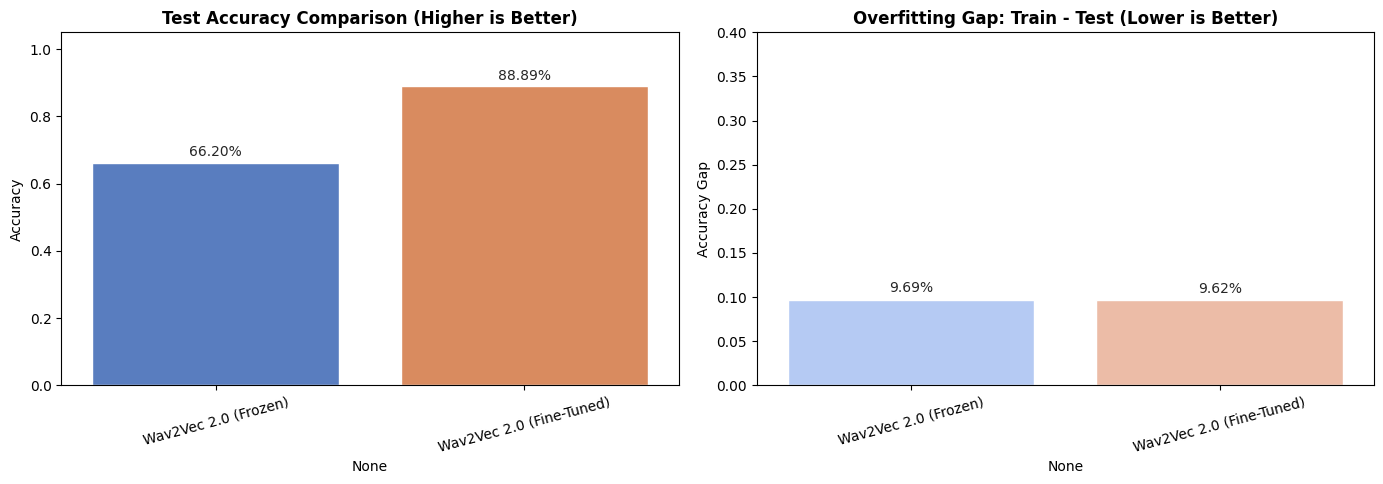

In [8]:
# Convert the results dictionary into a Pandas DataFrame
comparison_df = pd.DataFrame(results).T

if not comparison_df.empty:
    # Rename columns for presentation
    comparison_df = comparison_df.rename(columns={
        "train_acc": "Train Accuracy",
        "test_acc": "Test Accuracy",
        "gap": "Train-Test Gap"
    })
    
    # Print the Leaderboard Table
    print("====================================================================")
    print("                        MODEL LEADERBOARD")
    print("====================================================================")
    display(comparison_df.round(4))
    print("\n")
    
    # Create Accuracy and Overfitting Gap Plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.set_theme(style="whitegrid")
    
    # Plot 1: Test Accuracy Comparison (Higher is Better)
    bars1 = sns.barplot(
        x=comparison_df.index, 
        y=comparison_df["Test Accuracy"], 
        ax=axes[0], 
        palette="muted"
    )
    axes[0].set_title("Test Accuracy Comparison (Higher is Better)", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_ylim(0, 1.05)
    axes[0].tick_params(axis='x', rotation=15)
    
    # Add values on top of the bars
    for bar in bars1.patches:
        val = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width()/2, 
            val + 0.01, 
            f"{val:.2%}", 
            ha="center", 
            va="bottom", 
            fontsize=10
        )
        
    # Plot 2: Overfitting Gap (Lower is Better)
    bars2 = sns.barplot(
        x=comparison_df.index, 
        y=comparison_df["Train-Test Gap"], 
        ax=axes[1], 
        palette="coolwarm"
    )
    axes[1].set_title("Overfitting Gap: Train - Test (Lower is Better)", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("Accuracy Gap")
    axes[1].set_ylim(min(0, comparison_df["Train-Test Gap"].min() - 0.05), max(0.4, comparison_df["Train-Test Gap"].max() + 0.05))
    axes[1].tick_params(axis='x', rotation=15)
    
    # Add values on top of the bars
    for bar in bars2.patches:
        val = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width()/2, 
            val + 0.005 if val >= 0 else val - 0.015, 
            f"{val:.2%}", 
            ha="center", 
            va="bottom" if val >= 0 else "top", 
            fontsize=10
        )
        
    plt.tight_layout()
    plt.show()
else:
    print("No results found in the 'results' dictionary yet. Please run and evaluate at least one model.")